# Ejercicio 1 — Detección de curvatura: diseño $3^2$ vs. $2^2$

**Objetivo.** Comparar la capacidad de un diseño factorial a dos niveles ($2^2$) y a
tres niveles ($3^2$) para detectar curvatura en la relación entre los factores y la
respuesta. Ajustar modelos lineal y cuadrático, diagnosticar falta de ajuste y concluir
cuándo es necesario el tercer nivel.

**Factores:**
- $A$ = Temperatura de reacción: 60 (−1), 75 (0), 90 °C (+1)
- $B$ = Concentración del catalizador: 10 (−1), 15 (0), 20 g/L (+1)

**Respuesta:** Rendimiento de reacción (%)

**Dataset:** `../../datos/rendimiento-reaccion-3k.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

df = pd.read_csv('../../datos/rendimiento-reaccion-3k.csv')
print(df)

   x1  x2  A_real  B_real  rendimiento
0  -1  -1      60      10         52.3
1  -1   0      60      15         61.8
2  -1   1      60      20         58.4
3   0  -1      75      10         63.5
4   0   0      75      15         74.2
5   0   1      75      20         70.6
6   1  -1      90      10         68.9
7   1   0      90      15         82.1
8   1   1      90      20         77.4


## 1. Subconjunto $2^2$: solo los 4 vértices

Extraemos las 4 corridas con $x_1, x_2 \in \{-1, +1\}$ y ajustamos un modelo puramente lineal.

In [2]:
df22 = df[df['x1'].isin([-1, 1]) & df['x2'].isin([-1, 1])].copy()
print('Corridas del subconjunto 2^2:')
print(df22[['x1','x2','rendimiento']])

modelo_lineal = smf.ols('rendimiento ~ x1 + x2 + x1:x2', data=df22).fit()
print('\nModelo lineal (2^2):')
print(modelo_lineal.summary())
print()
print('⚠ NOTA: El 2^2 con interacción tiene 4 parámetros y solo 4 observaciones')
print('   → modelo SATURADO: 0 grados de libertad para el error, R²=1, sin p-valores.')
print('   Esto no es un error del software — es exactamente la limitación que motiva el')
print('   tercer nivel: sin réplicas ni puntos intermedios, no podemos estimar el error.')

Corridas del subconjunto 2^2:
   x1  x2  rendimiento
0  -1  -1         52.3
2  -1   1         58.4
6   1  -1         68.9
8   1   1         77.4

Modelo lineal (2^2):
                            OLS Regression Results                            
Dep. Variable:            rendimiento   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 01 Jul 2026   Prob (F-statistic):                nan
Time:                        18:11:04   Log-Likelihood:                 124.19
No. Observations:                   4   AIC:                            -240.4
Df Residuals:                       0   BIC:                            -242.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t

C:\Users\delram\miniconda3\envs\doe_2026\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
C:\Users\delram\miniconda3\envs\doe_2026\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
C:\Users\delram\miniconda3\envs\doe_2026\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
C:\Users\delram\miniconda3\envs\doe_2026\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
C:\Users\delram\miniconda3\envs\doe_2026\Lib\site-packages\statsmodels\

## 2. Diseño $3^2$ completo: modelo cuadrático

Con las 9 corridas ajustamos el modelo de segundo orden incluyendo términos cuadráticos.

In [3]:
modelo_cuad = smf.ols('rendimiento ~ x1 + x2 + I(x1**2) + I(x2**2) + x1:x2',
                      data=df).fit()
print('Modelo cuadrático (3^2):')
print(modelo_cuad.summary())

Modelo cuadrático (3^2):
                            OLS Regression Results                            
Dep. Variable:            rendimiento   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     195.6
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           0.000573
Time:                        18:11:04   Log-Likelihood:                -6.4942
No. Observations:                   9   AIC:                             24.99
Df Residuals:                       3   BIC:                             26.17
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     74.4444      

## 3. Diagnóstico de falta de ajuste

Comparamos los dos modelos: el modelo lineal del $2^2$ genera predicciones para las
corridas del nivel central ($x_1=0, x_2=0$) que podemos contrastar con la observación real.
Una discrepancia grande indica curvatura.

In [4]:
# Predicción del modelo lineal en el punto central
centro = pd.DataFrame({'x1': [0], 'x2': [0]})
pred_lineal_centro = modelo_lineal.predict(centro)[0]
y_centro_obs = df.loc[(df['x1']==0) & (df['x2']==0), 'rendimiento'].values[0]

print(f'Predicción lineal en (0,0): {pred_lineal_centro:.2f}')
print(f'Observación real en (0,0):  {y_centro_obs:.2f}')
print(f'Diferencia (curvatura):     {y_centro_obs - pred_lineal_centro:.2f}')

# Coeficientes cuadráticos del modelo 3^2
b11 = modelo_cuad.params['I(x1 ** 2)']
b22 = modelo_cuad.params['I(x2 ** 2)']
p11 = modelo_cuad.pvalues['I(x1 ** 2)']
p22 = modelo_cuad.pvalues['I(x2 ** 2)']
print(f'\nβ₁₁ (curvatura A): {b11:.3f}  (p={p11:.4f})')
print(f'β₂₂ (curvatura B): {b22:.3f}  (p={p22:.4f})')

Predicción lineal en (0,0): 64.25
Observación real en (0,0):  74.20
Diferencia (curvatura):     9.95

β₁₁ (curvatura A): -2.617  (p=0.0233)
β₂₂ (curvatura B): -7.517  (p=0.0012)


## 4. Tabla de ANOVA comparativa

In [5]:
anova_cuad = sm.stats.anova_lm(modelo_cuad, typ=1)
print('ANOVA — Modelo cuadrático (3^2):')
print(anova_cuad.round(4))

ANOVA — Modelo cuadrático (3^2):
             df    sum_sq   mean_sq         F  PR(>F)
x1          1.0  520.8017  520.8017  700.2811  0.0001
x2          1.0   78.4817   78.4817  105.5281  0.0020
I(x1 ** 2)  1.0   13.6939   13.6939   18.4131  0.0233
I(x2 ** 2)  1.0  113.0006  113.0006  151.9430  0.0012
x1:x2       1.0    1.4400    1.4400    1.9363  0.2583
Residual    3.0    2.2311    0.7437       NaN     NaN


## 5. Visualización: superficie de respuesta ajustada

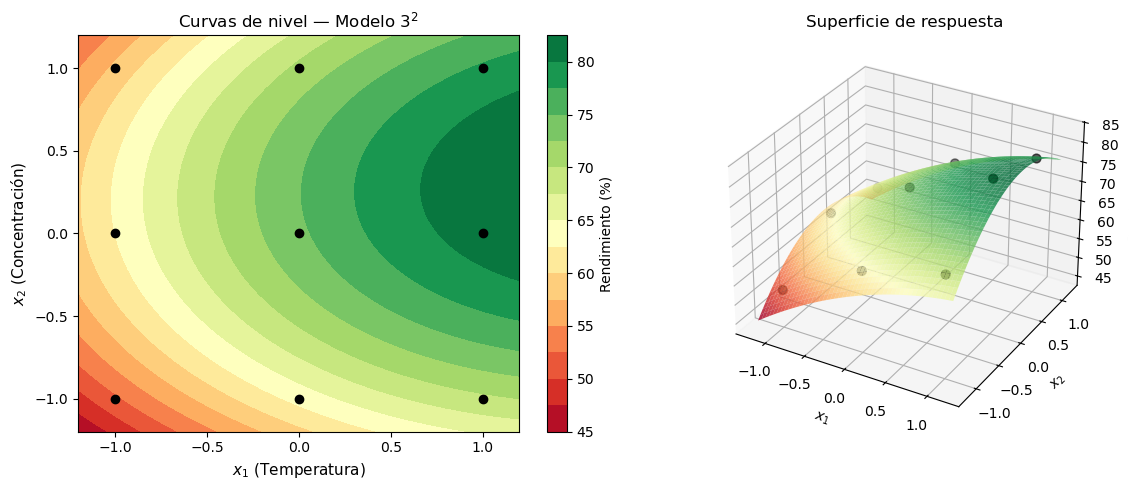

In [6]:
x1g, x2g = np.meshgrid(np.linspace(-1.2, 1.2, 50), np.linspace(-1.2, 1.2, 50))
grid = pd.DataFrame({'x1': x1g.ravel(), 'x2': x2g.ravel()})
zg = modelo_cuad.predict(grid).values.reshape(x1g.shape)

fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')

# Contornos
cp = ax0.contourf(x1g, x2g, zg, levels=15, cmap='RdYlGn')
ax0.scatter(df['x1'], df['x2'], c='black', zorder=5)
ax0.set_xlabel('$x_1$ (Temperatura)', fontsize=11)
ax0.set_ylabel('$x_2$ (Concentración)', fontsize=11)
ax0.set_title('Curvas de nivel — Modelo $3^2$')
plt.colorbar(cp, ax=ax0, label='Rendimiento (%)')

# Superficie 3D
ax3d.plot_surface(x1g, x2g, zg, cmap='RdYlGn', alpha=0.8)
ax3d.scatter(df['x1'], df['x2'], df['rendimiento'], c='black', s=40, zorder=5)
ax3d.set_xlabel('$x_1$')
ax3d.set_ylabel('$x_2$')
ax3d.set_zlabel('Rendimiento')
ax3d.set_title('Superficie de respuesta')

plt.tight_layout()
plt.show()

## 6. Conclusión

- El diseño **$2^2$** (4 vértices) ajusta solo relaciones lineales y no puede detectar curvatura.
- El diseño **$3^2$** revela si $\hat\beta_{11}$ o $\hat\beta_{22}$ son significativos.
- Si la curvatura es importante, el $3^2$ indica que un **CCD** o **Box-Behnken** permitirá
  localizar el óptimo con mayor precisión.

> **Regla práctica.** Cuando la diferencia $|y_{\text{centro}} - \hat{y}_{\text{lineal}}|$
> es grande en relación con el error experimental, la curvatura es real y justifica tres niveles.